<a href="https://colab.research.google.com/github/loopBreakerr/tr-economy-ml-analysis/blob/main/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 AYLIK ENFLASYON TAHMİNİ İÇİN MAE (Yüzde Puanı Sapması): 1.05


<Figure size 1000x600 with 0 Axes>

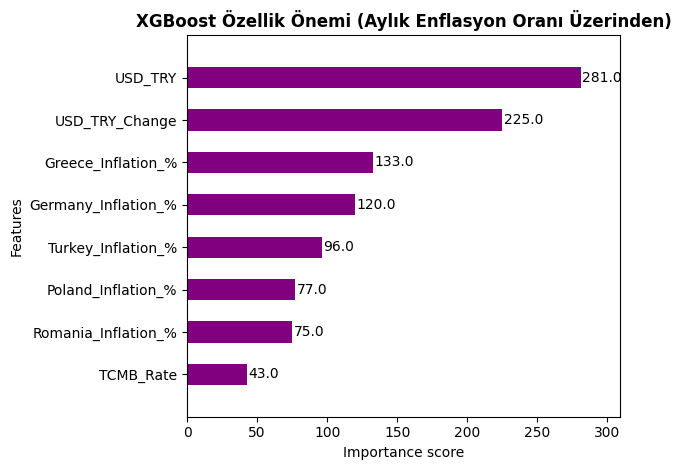

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Veri İthalatı
df = pd.read_csv('master_dataset_v2.csv', index_col=0, parse_dates=True)

# 2. FEATURE ENGINEERING (Dönüşüm Noktası)
# Tüm ülkelerin ham endeks puanlarını Aylık Enflasyon Oranına (% değişim) çeviriyoruz.
ülkeler = ['Turkey', 'Germany', 'Poland', 'Greece', 'Romania']
for ulke in ülkeler:
    if ulke in df.columns:
        df[f'{ulke}_Inflation_%'] = df[ulke].pct_change() * 100

# Ham endeks kolonlarını atıyoruz, çünkü artık yüzdelik enflasyonlarla (Stationary Data) çalışacağız
df.drop(columns=ülkeler, inplace=True, errors='ignore')
df.dropna(inplace=True)

# 3. Target Generation (Gelecek Ayın Türkiye Enflasyon Oranı)
df['Target_TR_Inflation_Next_Month'] = df['Turkey_Inflation_%'].shift(-1)
df_model = df.dropna()

# 4. Splitting
X = df_model.drop(columns=['Target_TR_Inflation_Next_Month'])
y = df_model['Target_TR_Inflation_Next_Month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. Model Execution
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluation
predictions = model.predict(X_test)
print(f"📊 AYLIK ENFLASYON TAHMİNİ İÇİN MAE (Yüzde Puanı Sapması): {mean_absolute_error(y_test, predictions):.2f}")

# 7. Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=10, height=0.5, color='purple')
plt.title('XGBoost Özellik Önemi (Aylık Enflasyon Oranı Üzerinden)', fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()